# SI 630 Homework 3

This notebook covers:

- **Part 1** reflection and annotation-file loading
- **Part 2** model training with RoBERTa + Hugging Face `Trainer`
- **Problem 6** Weights & Biases logging and model selection
- **Problem 7** evaluation on the 100 manually annotated examples



## Load files


In [ ]:
import os
import json
import random
import warnings

import numpy as np
import pandas as pd
import torch
import wandb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    ProgressCallback,
)
from transformers.utils.notebook import NotebookProgressCallback

os.environ["WANDB_NOTEBOOK_NAME"] = "hw3_updated_clean.ipynb"

SEED = 440
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PERSPECTRUM_FILE = "perspectrum_with_answers_v1.0.json"
PERSPECTIVE_POOL_FILE = "perspective_pool_v1.0.json"
ANNOTATED_FILE = "annotated_sample_100.csv"
MODEL_NAME = "roberta-base"

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


: 

## Problem 3 reflection


In [ ]:
reflection = (
    "The annotation process made me realize that stance labeling is usually easier than relevance "
    "labeling, because many perspectives clearly support or oppose a claim, while relevance often "
    "sits on a spectrum and requires more judgment. I learned how important it is to separate "
    "agreement from topical fit. A perspective can be strongly worded and still be only somewhat "
    "relevant if it addresses a side issue rather than the core issue. It did not feel hard, but "
    "it was tedious. It was a little challenging when wording became vague and broad. A next "
    "iteration of the task would benefit from clearer annotation guidelines, especially with more "
    "edge-case examples showing the difference between 'directly relevant' and 'somewhat relevant'. "
    "Overall, the exercise changed my perception of annotation by showing me that it is not just "
    "mechanical labeling; it is a careful interpretive process where good definitions and "
    "consistency matter as much as the labels themselves."
)
print(reflection)


## Preview the annotated sample

In [ ]:
annotated_df = pd.read_csv(ANNOTATED_FILE)
print("Annotated rows:", len(annotated_df))
print(annotated_df.head())


## Problem 4 setup note

I set up a Python virtual environment on Great Lakes, installed the required packages, copied the dataset and annotation files to the cluster, and verified that PyTorch could detect a GPU before training.


## Part 2: training data construction

 trained from `perspectrum_with_answers_v1.0.json`, and stance/relevance labels  derived from `stance_label_5`.


In [ ]:
wandb.login()


In [ ]:
with open(PERSPECTRUM_FILE, "r", encoding="utf-8") as f:
    perspectrum_data = json.load(f)

with open(PERSPECTIVE_POOL_FILE, "r", encoding="utf-8") as f:
    perspective_pool_data = json.load(f)

print("Number of claims:", len(perspectrum_data))
print("Number of perspective pool items:", len(perspective_pool_data))

pid_to_text = {item["pId"]: item["text"] for item in perspective_pool_data}
print("Lookup size:", len(pid_to_text))


## Label mapping and cleaning helpers


In [ ]:
def normalize_stance_label(label: str) -> str:
    """Normalize label text from the dataset into a stable lowercase format."""
    label = str(label).strip().lower()
    label = label.replace("_", " ").replace("-", " ")
    label = " ".join(label.split())
    return label

def map_labels(stance_label_5: str):
    """Map stance_label_5 to two binary targets:
    - stance_support: 1 = support, 0 = oppose
    - relevance_direct: 1 = directly relevant, 0 = somewhat relevant
    """
    label = normalize_stance_label(stance_label_5)

    if label == "support":
        return 1, 1
    if label == "undermine":
        return 0, 1
    if label == "mildly support":
        return 1, 0
    if label == "mildly undermine":
        return 0, 0
    return None

def is_not_valid_perspective(voter_counts):
    return len(voter_counts) > 4 and voter_counts[-1] > 0


In [ ]:
rows = []

for claim in perspectrum_data:
    cid = claim["cId"]
    claim_text = claim["text"]

    for perspective_group in claim["perspectives"]:
        pids = perspective_group["pids"]
        stance_label_5 = perspective_group["stance_label_5"]
        voter_counts = perspective_group["voter_counts"]


        if is_not_valid_perspective(voter_counts):
            continue

        if normalize_stance_label(stance_label_5) == "no majority label":
            continue

        mapped = map_labels(stance_label_5)
        if mapped is None:
            continue

        stance_support, relevance_direct = mapped

        if not pids:
            continue

        for pid in pids:
            perspective_text = pid_to_text.get(pid)
            if perspective_text is None:
                continue

            rows.append(
                {
                    "cid": cid,
                    "claim_text": claim_text,
                    "pid": pid,
                    "perspective_text": perspective_text,
                    "stance_label_5": stance_label_5,
                    "stance_support": stance_support,
                    "relevance_direct": relevance_direct,
                }
            )

df = pd.DataFrame(rows).drop_duplicates()

print("Training rows after cleaning:", len(df))
print(df.head())


## Sanity checks on the processed labels

The assignment expects relevance to be derived from both strong and mild stance labels, so the processed data should ideally contain both `relevance_direct = 1` and `relevance_direct = 0`.


In [ ]:
print("stance_label_5 distribution:")
print(df["stance_label_5"].apply(normalize_stance_label).value_counts(dropna=False))

print("\nrelevance_direct distribution:")
print(df["relevance_direct"].value_counts(dropna=False))

print("\nstance_support distribution:")
print(df["stance_support"].value_counts(dropna=False))

print("\nJoint label distribution:")
print(df[["stance_support", "relevance_direct"]].value_counts())

if df["relevance_direct"].nunique() < 2:
    warnings.warn(
        "Only one relevance class is present after preprocessing. "
        "This would make the relevance part of the multilabel task degenerate. "
        "Double-check the raw stance_label_5 values and the label mapping."
    )


In [ ]:
df["labels"] = df.apply(
    lambda row: [float(row["stance_support"]), float(row["relevance_direct"])],
    axis=1,
)

print(df[["claim_text", "perspective_text", "stance_label_5", "stance_support", "relevance_direct", "labels"]].head())


## Train / dev split

joint stance-relevance label so the development set keeps approximately the same label mix as the training set

In [ ]:
joint_label = df["stance_support"].astype(str) + "_" + df["relevance_direct"].astype(str)

train_df, dev_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=joint_label
)

train_df = train_df.reset_index(drop=True)
dev_df = dev_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Dev size:", len(dev_df))

print("\nTrain joint-label distribution:")
print(train_df[["stance_support", "relevance_direct"]].value_counts())

print("\nDev joint-label distribution:")
print(dev_df[["stance_support", "relevance_direct"]].value_counts())


## Convert to Hugging Face datasets


In [ ]:
train_dataset = Dataset.from_pandas(
    train_df[["claim_text", "perspective_text", "labels"]],
    preserve_index=False
)

dev_dataset = Dataset.from_pandas(
    dev_df[["claim_text", "perspective_text", "labels"]],
    preserve_index=False
)

print(train_dataset)
print(dev_dataset)


## Tokenization

I use RoBERTa with paired inputs `(claim_text, perspective_text)` and truncate sequences to length 256.


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["claim_text"],
        examples["perspective_text"],
        truncation=True,
        padding=False,
        max_length=256,
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
dev_dataset = dev_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
dev_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


## Model and metrics

multilabel setup with two jointly predicted binary labels, so the model uses `problem_type="multi_label_classification"` and evaluation thresholds sigmoid outputs at 0.5.


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    problem_type="multi_label_classification",
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)

    micro_f1 = f1_score(labels, preds, average="micro", zero_division=0)
    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)
    subset_acc = accuracy_score(labels, preds)

    return {
        "micro_f1": micro_f1,
        "macro_f1": macro_f1,
        "subset_accuracy": subset_acc,
    }


## Training

W&B is enabled so that development-set performance can be inspected . The model-selection metric is `micro_f1`.


In [ ]:
training_args = TrainingArguments(
    output_dir="outputs/roberta_hw3",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="micro_f1",
    greater_is_better=True,
    report_to="wandb",
    run_name="roberta_hw3_final",
    save_total_limit=2,
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


In [ ]:
train_output = trainer.train()

try:
    trainer.remove_callback(NotebookProgressCallback)
except Exception:
    pass

trainer.add_callback(ProgressCallback)

dev_results = trainer.evaluate()
print(dev_results)


## Problem 6 model choice

I used Weights & Biases to track development-set performance during training, including validation loss, micro-F1, macro-F1, and subset accuracy over time, as required by the assignment. The curves show that training loss decreased steadily, while development micro-F1, macro-F1, and subset accuracy improved across epochs. Validation loss was lowest earlier in training, but the final checkpoint achieved the strongest development micro-F1, which was the model-selection metric specified in my TrainingArguments.

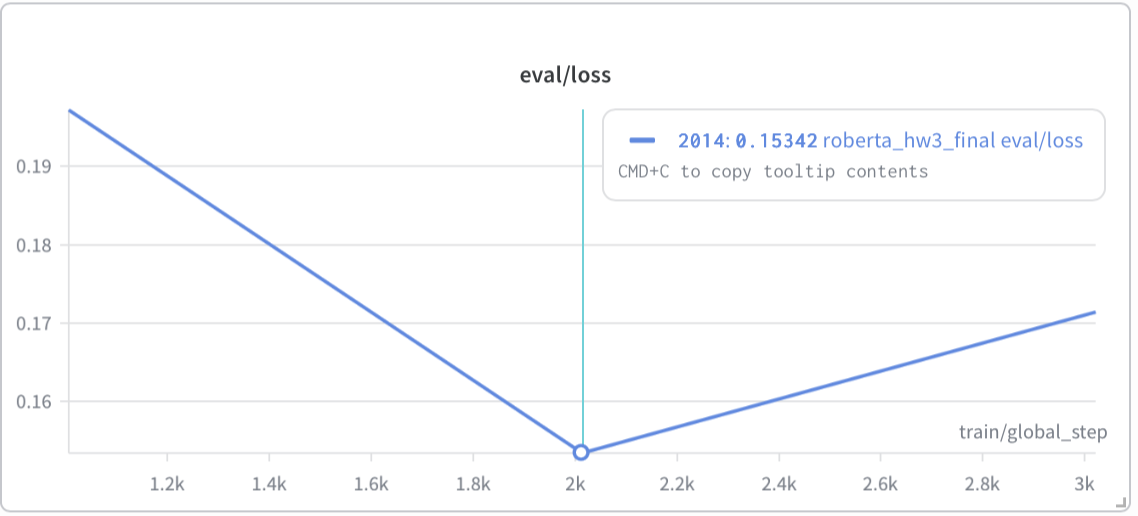

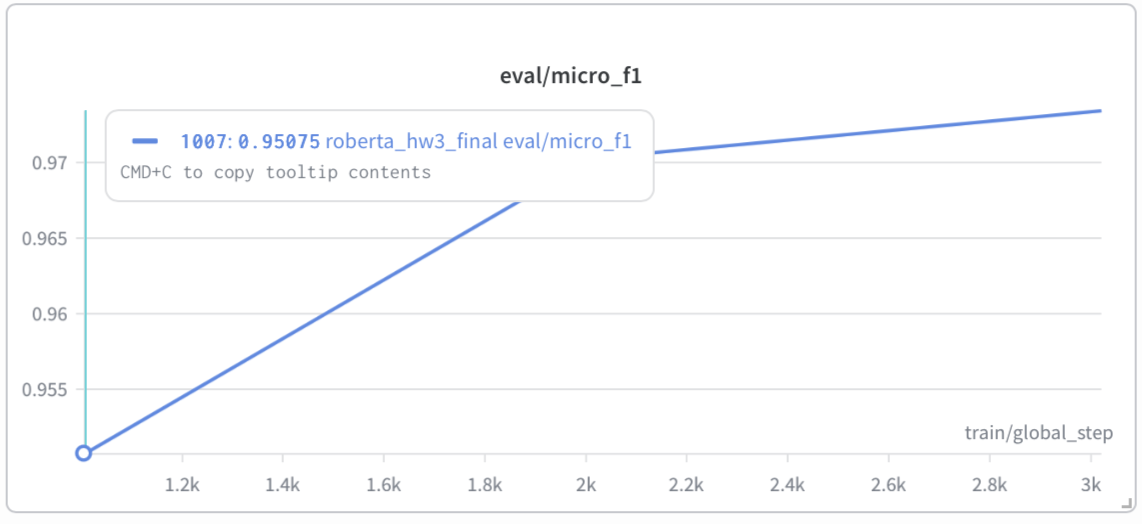

## Problem 7: evaluate on the manually annotated 100-row dataset


In [ ]:
test_df = pd.read_csv(ANNOTATED_FILE)

test_df["stance_annotation"] = test_df["stance_annotation"].astype(str).str.strip().str.lower()
test_df["relevance_annotation"] = test_df["relevance_annotation"].astype(str).str.strip().str.lower()

# Gold stance: support = 1, oppose = 0
test_df["gold_stance"] = test_df["stance_annotation"].map({
    "support": 1,
    "oppose": 0,
})

# directly relevant = 1, somewhat relevant = 0
test_df["gold_relevance"] = test_df["relevance_annotation"].map({
    "directly relevant": 1,
    "somewhat relevant": 0,
})

print("Test rows:", len(test_df))
print(test_df[["claim_text", "perspective_text", "stance_annotation", "relevance_annotation"]].head())
print("\nStance label distribution:")
print(test_df["stance_annotation"].value_counts(dropna=False))
print("\nRelevance label distribution:")
print(test_df["relevance_annotation"].value_counts(dropna=False))


In [ ]:
test_dataset = Dataset.from_pandas(
    test_df[["claim_text", "perspective_text"]],
    preserve_index=False,
)

def tokenize_test(examples):
    return tokenizer(
        examples["claim_text"],
        examples["perspective_text"],
        truncation=True,
        padding=False,
        max_length=256,
    )

test_dataset = test_dataset.map(tokenize_test, batched=True)
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask"])

pred_output = trainer.predict(test_dataset)
logits = pred_output.predictions

probs = 1 / (1 + np.exp(-logits))
preds = (probs >= 0.5).astype(int)

test_df["pred_stance"] = preds[:, 0]
test_df["pred_relevance"] = preds[:, 1]

test_df["pred_stance_label"] = test_df["pred_stance"].map({1: "support", 0: "oppose"})
test_df["pred_relevance_label"] = test_df["pred_relevance"].map({
    1: "directly relevant",
    0: "somewhat relevant",
})

print(
    test_df[
        [
            "claim_text",
            "perspective_text",
            "stance_annotation",
            "pred_stance_label",
            "relevance_annotation",
            "pred_relevance_label",
        ]
    ].head()
)


In [ ]:
# Stance evaluation
stance_eval_df = test_df.dropna(subset=["gold_stance"]).copy()

print("STANCE CLASSIFICATION REPORT")
print(
    classification_report(
        stance_eval_df["gold_stance"],
        stance_eval_df["pred_stance"],
        target_names=["oppose", "support"],
        zero_division=0,
    )
)

cm_stance = confusion_matrix(
    stance_eval_df["gold_stance"],
    stance_eval_df["pred_stance"],
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_stance,
    display_labels=["oppose", "support"],
)
disp.plot()
plt.title("Stance Confusion Matrix")
plt.show()

# Relevance evaluation
relevance_eval_df = test_df.dropna(subset=["gold_relevance"]).copy()

print("RELEVANCE CLASSIFICATION REPORT")
print(
    classification_report(
        relevance_eval_df["gold_relevance"],
        relevance_eval_df["pred_relevance"],
        target_names=["somewhat relevant", "directly relevant"],
        zero_division=0,
    )
)

cm_rel = confusion_matrix(
    relevance_eval_df["gold_relevance"],
    relevance_eval_df["pred_relevance"],
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rel,
    display_labels=["somewhat relevant", "directly relevant"],
)
disp.plot()
plt.title("Relevance Confusion Matrix")
plt.show()

test_df.to_csv("annotated_test_with_predictions.csv", index=False)
print("Saved prediction")


The model performed well on stance prediction, with balanced F1 scores for support and oppose. Relevance prediction was much weaker for the somewhat relevant class, likely because the derived training labels were highly imbalanced and because somewhat relevant is inherently more subjective than directly relevant. My annotated test set was also imbalanced, with 90 directly relevant examples and only 10 somewhat relevant examples, which likely made the minority class harder to learn and evaluate.

## Problem 8: Krippendorff's alpha from aggregated vote counts

For this section, I use only the first four entries of voter_counts
support, mildly support, mildly undermine, and undermine
I drop rows where all four entries are zero

I compute the coincidence matrix directly from the counts and then compute Krippendorff's alpha
under both nominal and interval distance functions.

In [ ]:
vote_rows = []

for claim in perspectrum_data:
    for perspective_group in claim["perspectives"]:
        vc = perspective_group["voter_counts"][:4]   #  first four fields
        if sum(vc) == 0:
            continue
        vote_rows.append(vc)

vote_df = pd.DataFrame(
    vote_rows,
    columns=["support", "mildly_support", "mildly_undermine", "undermine"]
)

print("Rows used for IAA:", len(vote_df))
print(vote_df.head())

In [ ]:
def coincidence_matrix_from_counts(count_matrix: np.ndarray) -> np.ndarray:

    n_categories = count_matrix.shape[1]
    O = np.zeros((n_categories, n_categories), dtype=float)

    for counts in count_matrix:
        n = counts.sum()
        if n <= 1:
            continue

        # Off-diagonal entries
        for i in range(n_categories):
            for j in range(n_categories):
                if i != j:
                    O[i, j] += (counts[i] * counts[j]) / (n - 1)

        # Diagonal entries
        for i in range(n_categories):
            O[i, i] += (counts[i] * (counts[i] - 1)) / (n - 1)

    return O

count_matrix = vote_df.to_numpy()
O = coincidence_matrix_from_counts(count_matrix)

print("Coincidence matrix:")
print(pd.DataFrame(
    O,
    index=vote_df.columns,
    columns=vote_df.columns
))

In [ ]:
def nominal_distance_matrix(n_categories: int) -> np.ndarray:
    D = np.ones((n_categories, n_categories), dtype=float)
    np.fill_diagonal(D, 0.0)
    return D

def interval_distance_matrix(n_categories: int) -> np.ndarray:
    D = np.zeros((n_categories, n_categories), dtype=float)
    for i in range(n_categories):
        for j in range(n_categories):
            D[i, j] = (i - j) ** 2
    return D

D_nominal = nominal_distance_matrix(4)
D_interval = interval_distance_matrix(4)

print("Nominal distance matrix:")
print(pd.DataFrame(D_nominal, index=vote_df.columns, columns=vote_df.columns))

print("\nInterval distance matrix:")
print(pd.DataFrame(D_interval, index=vote_df.columns, columns=vote_df.columns))

In [ ]:
def krippendorff_alpha_from_coincidence(O: np.ndarray, D: np.ndarray) -> float:
    """
    Compute Krippendorff's alpha from coincidence matrix O and distance matrix D
    """
    total = O.sum()
    if total == 0:
        return np.nan

    marginals = O.sum(axis=1)

    # Observed disagreement
    Do = (O * D).sum() / total

    # Expected disagreement
    E = np.outer(marginals, marginals)
    np.fill_diagonal(E, marginals * (marginals - 1))

    denom = E.sum()
    if denom == 0:
        return np.nan

    De = (E * D).sum() / denom

    if De == 0:
        return 1.0

    return 1 - (Do / De)

alpha_nominal = krippendorff_alpha_from_coincidence(O, D_nominal)
alpha_interval = krippendorff_alpha_from_coincidence(O, D_interval)

print("Krippendorff's alpha (nominal):", alpha_nominal)
print("Krippendorff's alpha (interval):", alpha_interval)

 constructed the coincidence matrix directly from aggregated counts. Krippendorff’s alpha was 0.5998 under the nominal distance function and 0.9191 under the interval distance function. The interval alpha is much higher because the four stance labels are ordered, so disagreements between nearby labels such as support and mildly support are penalized less than disagreements between far-apart labels such as support and undermine. This suggests that annotators often disagreed in a graded way rather than making completely opposite judgments.

## Problem 9: Agreement-level analysis

For each item, I compute the proportion of votes received by the majority label using the first four
stance categories only. I then group items into high, medium, and low agreement, construct a
separate coincidence matrix for each group, and compute Krippendorff's alpha on an interval scale.

In [ ]:
def majority_vote_proportion(counts):
    counts = np.array(counts)
    total = counts.sum()
    if total == 0:
        return np.nan
    return counts.max() / total

agreement_rows = []

for claim in perspectrum_data:
    for perspective_group in claim["perspectives"]:
        vc = perspective_group["voter_counts"][:4]
        if sum(vc) == 0:
            continue

        maj_prop = majority_vote_proportion(vc)

        if maj_prop >= 0.80:
            level = "High"
        elif maj_prop >= 0.60:
            level = "Medium"
        else:
            level = "Low"

        agreement_rows.append({
            "counts": vc,
            "majority_prop": maj_prop,
            "agreement_level": level
        })

agreement_df = pd.DataFrame(agreement_rows)

print(agreement_df["agreement_level"].value_counts())
agreement_df.head()

In [ ]:
group_alphas = {}

for level in ["High", "Medium", "Low"]:
    group_counts = np.vstack(
        agreement_df.loc[agreement_df["agreement_level"] == level, "counts"].to_list()
    )
    O_group = coincidence_matrix_from_counts(group_counts)
    alpha_group = krippendorff_alpha_from_coincidence(O_group, D_interval)
    group_alphas[level] = alpha_group

group_alphas

In [ ]:

levels = ["High", "Medium", "Low"]
alpha_values = [group_alphas[level] for level in levels]

plt.figure(figsize=(8, 5))
plt.bar(levels, alpha_values)
plt.ylabel("Krippendorff's alpha (interval)")
plt.title("Interval Krippendorff's Alpha by Agreement Level")

for i, v in enumerate(alpha_values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.ylim(0, max(alpha_values) + 0.1)
plt.show()

Using the first four stance categories from voter_counts and dropping rows where all four were zero, I constructed the coincidence matrix directly from aggregated counts, as required by the assignment. Krippendorff’s alpha was 0.5998 under the nominal distance function and 0.9191 under the interval distance function. The interval alpha is much higher because the four stance labels are ordered, so disagreements between nearby labels such as support and mildly support are penalized less than disagreements between far-apart labels such as support and undermine. This suggests that annotators often disagreed in a graded way rather than making completely opposite judgments.